<a href="https://colab.research.google.com/github/AnshuPrajapati29/deepfake-detection/blob/main/Dfake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")

print("Path to dataset files:", path)

100%|██████████| 1.68G/1.68G [00:24<00:00, 73.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*50)

/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1
Folders: ['Dataset']
Files: []
--------------------------------------------------
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset
Folders: ['Validation', 'Test', 'Train']
Files: []
--------------------------------------------------
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset/Validation
Folders: ['Fake', 'Real']
Files: []
--------------------------------------------------
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset/Validation/Fake
Folders: []
Files: ['fake_14637.jpg', 'fake_18039.jpg', 'fake_5280.jpg', 'fake_14748.jpg', 'fake_1750.jpg']
--------------------------------------------------
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset/Validation/Real
Folders: []
Files: ['real_3835.jpg', 'real_10064.jpg', 'real_17974.jpg', 'real_5659.jpg', 'real

In [ ]:
import os

# Adjusting paths to point to the 'Train' subset
real_dir = os.path.join(path, "Dataset", "Train", "Real")
fake_dir = os.path.join(path, "Dataset", "Train", "Fake")

print("Real (Train set):", len(os.listdir(real_dir)))
print("Fake (Train set):", len(os.listdir(fake_dir)))

Real (Train set): 70001
Fake (Train set): 70001


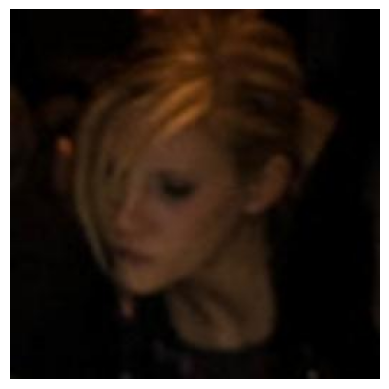

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

img_path = os.path.join(real_dir, os.listdir(real_dir)[0])

img = cv2.imread(img_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
import pandas as pd
import os

data = []

base_dataset_path = os.path.join(path, "Dataset")

# Iterate through Train, Validation, and Test subsets
for subset in ["Train", "Validation", "Test"]:
    for label_type in ["Real", "Fake"]:
        current_folder = os.path.join(base_dataset_path, subset, label_type)
        if os.path.exists(current_folder):
            for file in os.listdir(current_folder):
                data.append([
                    os.path.join(current_folder, file),
                    label_type.lower() # Store label as 'real' or 'fake'
                ])

df = pd.DataFrame(data, columns=["image_path", "label"])

df.head()

,image_path,label
0,/root/.cache/kagglehub/datasets/manjilkarki/de...,real
1,/root/.cache/kagglehub/datasets/manjilkarki/de...,real
2,/root/.cache/kagglehub/datasets/manjilkarki/de...,real
3,/root/.cache/kagglehub/datasets/manjilkarki/de...,real
4,/root/.cache/kagglehub/datasets/manjilkarki/de...,real


In [ ]:
df.shape

(190335, 2)

In [ ]:
df["label"].value_counts()

,count
label,
real,95201
fake,95134


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [ ]:
# Sample a smaller subset of the data for faster training
sample_fraction = 0.05 # Using 5% of the data

sampled_train_df = train_df.sample(frac=sample_fraction, random_state=42)
sampled_val_df = test_df.sample(frac=sample_fraction, random_state=42)

print(f"Sampled train data size: {len(sampled_train_df)}")
print(f"Sampled validation data size: {len(sampled_val_df)}")

Sampled train data size: 7613
Sampled validation data size: 1903


In [ ]:
# Function to load and preprocess images
def preprocess_image(image_path, label):
    # Load image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE) # Resize to target size

    # Convert label string to numerical (0 for 'fake', 1 for 'real')
    label = tf.cond(tf.equal(label, 'fake'), lambda: tf.constant(0), lambda: tf.constant(1))
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
print(path)
!find "$path" | head -30

/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset/Validation
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset/Validation/Fake
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset/Validation/Fake/fake_0.jpg
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset/Validation/Fake/fake_1.jpg
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset/Validation/Fake/fake_10.jpg
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset/Validation/Fake/fake_100.jpg
/root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Datase

In [ ]:
import tensorflow as tf
IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [ ]:
# Create TensorFlow datasets from sampled dataframes
train_ds = tf.data.Dataset.from_tensor_slices(
    (sampled_train_df["image_path"].values, sampled_train_df["label"].values)
)
train_ds = train_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

In [ ]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (sampled_val_df["image_path"].values, sampled_val_df["label"].values)
)
val_ds = val_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

In [ ]:
class_names = train_ds.class_names
print(class_names)

['Fake', 'Real']


In [ ]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(
    lambda x,y: (normalization_layer(x), y)
)
val_ds = val_ds.map(
    lambda x,y: (normalization_layer(x), y)
)

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [ ]:
base_model.trainable = False

In [ ]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 664s 3s/step - accuracy: 0.6972 - loss: 0.5773 - val_accuracy: 0.7373 - val_loss: 0.5340
Epoch 2/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 621s 3s/step - accuracy: 0.7531 - loss: 0.5080 - val_accuracy: 0.7562 - val_loss: 0.5080
Epoch 3/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 633s 3s/step - accuracy: 0.7642 - loss: 0.4871 - val_accuracy: 0.7662 - val_loss: 0.4954
Epoch 4/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 633s 3s/step - accuracy: 0.7733 - loss: 0.4752 - val_accuracy: 0.7735 - val_loss: 0.4887
Epoch 5/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 641s 3s/step - accuracy: 0.7749 - loss: 0.4687 - val_accuracy: 0.7777 - val_loss: 0.4854


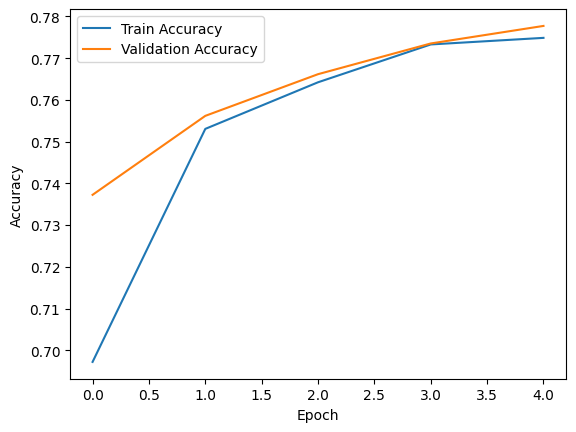

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

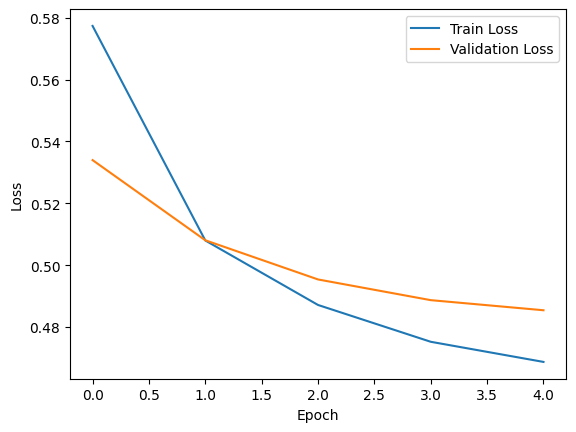

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
loss, acc = model.evaluate(val_ds)

print("Loss:", loss)
print("Accuracy:", acc)

60/60 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.7777 - loss: 0.4854
Loss: 0.4854152500629425
Accuracy: 0.7777193784713745


In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.81      0.79       966
           1       0.79      0.74      0.77       937

    accuracy                           0.78      1903
   macro avg       0.78      0.78      0.78      1903
weighted avg       0.78      0.78      0.78      1903



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[785 181]
 [242 695]]


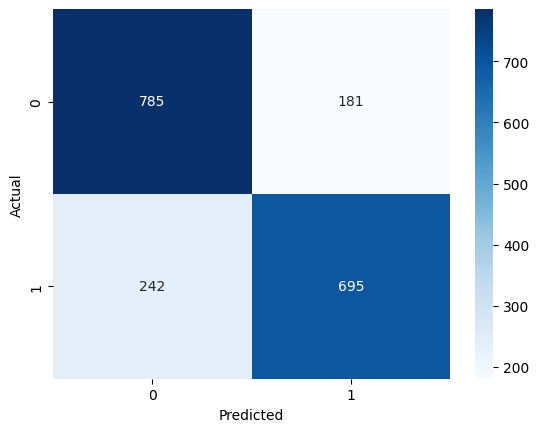

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
y_scores = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)

    y_scores.extend(preds.flatten())

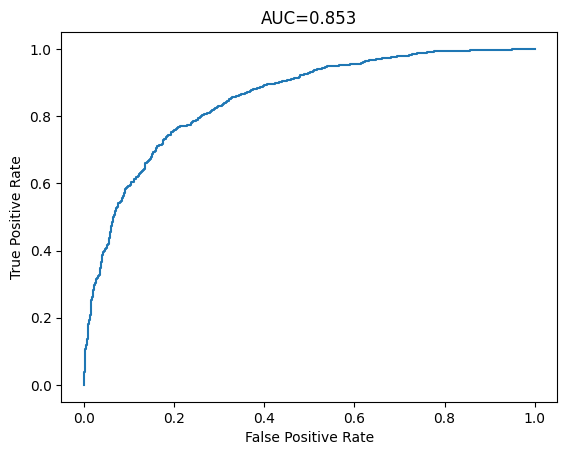

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"AUC={roc_auc:.3f}")
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving OIP.jpg to OIP (1).jpg


In [ ]:
import tensorflow as tf
import numpy as np

image_path=list(uploaded.keys())[0]

img=tf.keras.utils.load_img(
    image_path,
    target_size=(224,224)
)

img_array=tf.keras.utils.img_to_array(img)
img_array=img_array / 255.0
img_array=np.expand_dims(img_array, axis=0)

pred=model.predict(img_array)

print("Raw score:", pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
Raw score: 0.45126617


In [ ]:
if pred[0][0] > 0.5:
    print("Real")
else:
    print("Fake")

Fake


In [ ]:
model.save("deepfake_detector.h5")